# Validación de H(z): Python (`solve_sys.py`) vs C (`solve_sys_c`)

Este notebook:
1. Compara $H(z)$ de Python y C para ΛCDM, HS, ST y EXP (ramas analíticas y numéricas). Todas las diferencias se expresan como **diferencia relativa porcentual** $100\,|H_C/H_{Py}-1|$.
2. Valida que **ambas** implementaciones son correctas comparándolas con referencias independientes:
   - ΛCDM contra `astropy`.
   - HS y ST contra una **formulación distinta de las ecuaciones de campo** (sistema en $(E, R)$ obtenido de la ecuación de Friedmann), integrada con otro método (LSODA).
   - EXP contra una integración de alta precisión (Radau, `rtol=1e-12`).
   - Taylor (Basilakos et al.) contra la solución numérica para $b$ chico.
   - Vínculo $w = 1 + x + y - v$ y convergencia en la tolerancia.
3. Compara el $\chi^2$ de Python y C (diferencia porcentual).

In [1]:
import os, sys, time, types, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
warnings.filterwarnings('ignore')

import git
path_git = git.Repo('.', search_parent_directories=True).working_tree_dir
sys.path.append(os.path.join(path_git, 'fr_mcmc', 'utils'))

# chi_square importa ML (torch). Si torch no está instalado se reemplaza por un stub:
# la rama ML no se usa en este notebook.
try:
    import torch
except ImportError:
    ml = types.ModuleType('ML'); ml.H_ML = None; ml.ML_limits = lambda m: (0, 0, 0, 0)
    sys.modules['ML'] = ml

from solve_sys import Hubble_th as Hubble_py, integrator as integrator_py, get_odes
from solve_sys_c import Hubble_th as Hubble_c, integrator as integrator_c
from initial_conditions import calculate_initial_conditions, redshift_initial_condition
from LambdaCDM import H_LCDM
from taylor import Taylor_HS, Taylor_ST

def pct(a, b):
    '''Máxima diferencia relativa porcentual.'''
    return 100 * np.max(np.abs(np.asarray(a) / np.asarray(b) - 1))

N = int(1e5)
z_grid = np.linspace(0, 10, N)

## 1. $H(z)$: Python vs C

Tolerancias por defecto: `rtol=1e-8, atol=1e-10` (HS/ST en ambos y EXP en Python) y `rtol=1e-10, atol=1e-12` para EXP en C (ROS23 es de orden 2).
Para EXP, $b_{crit}=(4+\Omega_m/\Omega_\Lambda)/(-\ln\epsilon)\approx0.19$; por debajo se usa ΛCDM. Para HS/ST, $b\le0.15$ usa Taylor.
Las condiciones iniciales de HS/ST son las ΛCDM de `initial_conditions.py`, en $z_{ic}=30$ para HS (`Z_IC_HS`) y en $z_{ic}=z_{max}=10$ para ST (ver 2.3).

In [2]:
rows = []
for model in ['LCDM', 'HS', 'ST', 'EXP']:
    bs = [0.0] if model == 'LCDM' else [0.05, 0.15, 0.3, 0.5, 1.0, 2.0, 5.0]
    for om in [0.2, 0.3, 0.4]:
        for b in bs:
            p = [om, b, 70.0]
            if model == 'LCDM': rama = 'analítica'
            elif model == 'EXP': rama = 'ΛCDM' if b <= (4 + om/(1-om))/(-np.log(1e-10)) else 'numérica'
            else: rama = 'Taylor' if b <= 0.15 else 'numérica'
            try:
                t = time.time(); _, Hp = Hubble_py(p, model=model); tp = time.time() - t
            except Exception:
                Hp, tp = None, np.nan
            try:
                t = time.time(); _, Hc = Hubble_c(p, model=model); tc = time.time() - t
            except Exception:
                Hc, tc = None, np.nan
            if Hp is None or Hc is None:
                # ST con b grande: r cruza b/sqrt(3), donde f_RR = 0 (modelo inestable)
                rama += ' (falla Py:%s C:%s)' % ('no' if Hp is not None else 'sí', 'no' if Hc is not None else 'sí')
                d = np.nan
            else:
                d = pct(Hc, Hp)
            rows.append(dict(modelo=model, Om=om, b=b, rama=rama, **{'max|ΔH/H| [%]': d},
                             t_py_ms=1e3*tp, t_C_ms=1e3*tc))
df_H = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: '%.3g' % x)
df_H

,modelo,Om,b,rama,max|ΔH/H| [%],t_py_ms,t_C_ms
0,LCDM,0.2,0,analítica,4.44e-14,8.24,1.94
1,LCDM,0.3,0,analítica,4.44e-14,6.13,1.45
2,LCDM,0.4,0,analítica,4.44e-14,5.69,0.927
3,HS,0.2,0.05,Taylor,6.77e-13,130,13.7
4,HS,0.2,0.15,Taylor,6.88e-13,45,13.6
...,...,...,...,...,...,...,...
61,EXP,0.4,0.3,numérica,4.05e-08,705,39
62,EXP,0.4,0.5,numérica,1.59e-07,525,32.2
63,EXP,0.4,1,numérica,1.11e-06,586,30.8
64,EXP,0.4,2,numérica,1.89e-06,601,34.8


In [3]:
print(df_H.groupby(['modelo', 'rama'])['max|ΔH/H| [%]'].max().to_string())

modelo  rama                       
EXP     numérica                      2.33e-06
        ΛCDM                          4.44e-14
HS      Taylor                        7.77e-13
        numérica                      5.36e-09
LCDM    analítica                     4.44e-14
ST      Taylor                        7.77e-13
        numérica                      4.64e-09
        numérica (falla Py:sí C:sí)        NaN


**ST con $b$ grande** ($b\gtrsim4$ según $\Omega_m$): durante la evolución $r=R/\Lambda$ cae hasta $b/\sqrt{3}$, donde $f_{RR}=0$ y $\Gamma\to\infty$; debajo $f_{RR}<0$ (modelo inestable). Ambas implementaciones detectan esto y fallan (el $\chi^2$ devuelve $+\infty$, o sea, el punto se rechaza). Antes Python quedaba integrando con pasos cada vez más chicos.

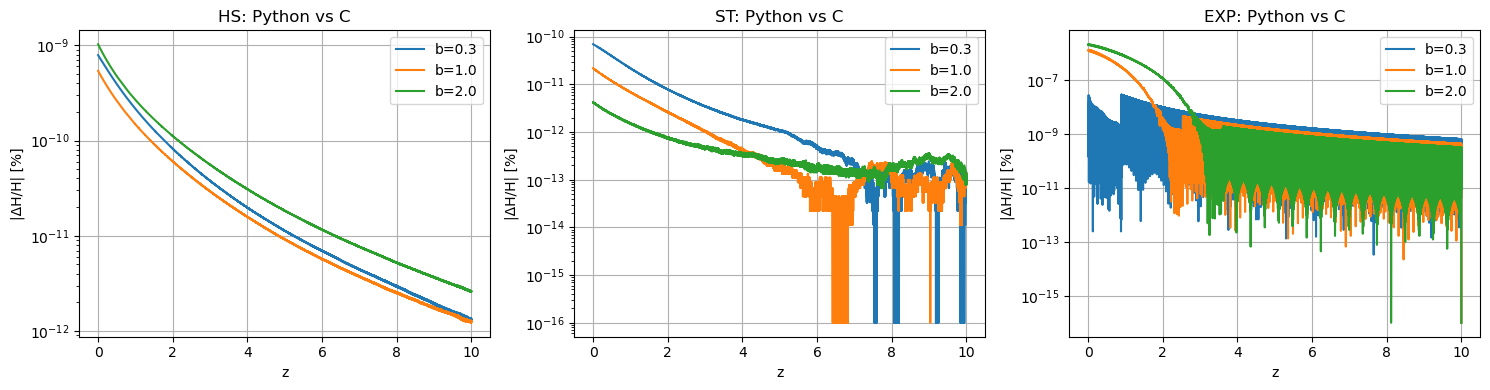

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, model in zip(axs, ['HS', 'ST', 'EXP']):
    for b in [0.3, 1.0, 2.0]:
        z, Hp = Hubble_py([0.3, b, 70], model=model); _, Hc = Hubble_c([0.3, b, 70], model=model)
        ax.semilogy(z, 100*np.abs(Hc/Hp - 1) + 1e-16, label=f'b={b}')
    ax.set_title(f'{model}: Python vs C'); ax.set_xlabel('z'); ax.set_ylabel('|ΔH/H| [%]'); ax.legend(); ax.grid(True)
plt.tight_layout()

## 2. Validación independiente

### 2.1 ΛCDM contra astropy

In [5]:
from astropy.cosmology import FlatLambdaCDM
for om, H0 in [(0.25, 67), (0.3, 70), (0.35, 73)]:
    ref = FlatLambdaCDM(H0=H0, Om0=om, Tcmb0=0).H(z_grid).value
    print(f'Om={om}, H0={H0}:  Python {pct(Hubble_py([om,0,H0], model="LCDM")[1], ref):.1e} %   '
          f'C {pct(Hubble_c([om,0,H0], model="LCDM")[1], ref):.1e} %')

Om=0.25, H0=67:  Python 0.0e+00 %   C 4.4e-14 %
Om=0.3, H0=70:  Python 0.0e+00 %   C 4.4e-14 %
Om=0.35, H0=73:  Python 0.0e+00 %   C 4.4e-14 %


### 2.2 HS y ST contra una formulación independiente

El código resuelve el sistema de De la Cruz et al. en $(x, y, v, w, r)$. Como referencia independiente se usa el sistema en $(E, \tilde R)$ con $N=\ln a$, derivado directamente de la ecuación de Friedmann de $f(R)$:

$$\frac{dE}{dN} = \frac{R}{6H_0^2E} - 2E, \qquad
\frac{dR}{dN} = \frac{1}{f_{RR}}\left[\frac{\Omega_m e^{-3N}}{E^2} + \frac{f_R R - f}{6H_0^2E^2} - f_R\right],$$

con condiciones iniciales ΛCDM en $z=50$ (HS) o $z=10$ (ST) y LSODA (`rtol=1e-10`). Es la misma formulación que se usa para EXP, pero con la $f(R)$ de HS o ST. Este sistema relaja rápido hacia la solución física, así que es poco sensible a las condiciones iniciales.

In [6]:
def f_model(model, r, b):
    '''f/Λ, f_R y Λ·f_RR como funciones de r = R/Λ (n=1).'''
    if model == 'HS':
        return r - 2 + 2*b/(b + r), 1 - 2*b/(b + r)**2, 4*b/(b + r)**3
    u = b**2 + r**2
    return r - 2 + 2*b**2/u, 1 - 4*b**2*r/u**2, 4*b**2*(3*r**2 - b**2)/u**3

def H_ER(model, om, b, H0, zs, zi=None, rtol=1e-10):
    '''H(z) resolviendo el sistema (E, R) de Friedmann (formulación independiente).
    zi: z=50 para HS; z=10 para ST (en ST el sistema es muy rígido a z alto y la
    dependencia con zi es ~1e-5 %).'''
    if zi is None:
        zi = 50 if model == 'HS' else 10
    OL = 1 - om; Lam = 3*OL
    def rhs(N, s):
        E, r = s; f, F, LFR = f_model(model, r, b)
        return [OL*r/(2*E) - 2*E, (om*np.exp(-3*N)/E**2 + Lam*(F*r - f)/(6*E**2) - F)/LFR]
    E0 = np.sqrt(om*(1 + zi)**3 + OL); r0 = (3*om*(1 + zi)**3 + 12*OL)/Lam
    Ns = -np.log1p(zs[::-1])
    sol = solve_ivp(rhs, (-np.log1p(zi), Ns[-1]), [E0, r0], t_eval=Ns, method='LSODA', rtol=rtol, atol=rtol*1e-3)
    assert sol.success
    return H0*sol.y[0][::-1]

z_ref = np.linspace(0, 10, 2001)
rows = []
for model in ['HS', 'ST']:
    for om in [0.2, 0.3, 0.4]:
        for b in [0.2, 0.5, 1.0, 2.0, 3.0]:
            ref = H_ER(model, om, b, 70, z_ref)
            _, Hp = Hubble_py([om, b, 70], model=model, num_z_points=2001)
            _, Hc = Hubble_c([om, b, 70], model=model, num_z_points=2001)
            rows.append(dict(modelo=model, Om=om, b=b, **{'Python vs (E,R) [%]': pct(Hp, ref), 'C vs (E,R) [%]': pct(Hc, ref)}))
df_ER = pd.DataFrame(rows); df_ER

,modelo,Om,b,"Python vs (E,R) [%]","C vs (E,R) [%]"
0,HS,0.2,0.2,0.00233,0.00233
1,HS,0.2,0.5,0.00573,0.00573
2,HS,0.2,1,0.0106,0.0106
3,HS,0.2,2,0.0211,0.0211
4,HS,0.2,3,0.0353,0.0353
5,HS,0.3,0.2,0.00112,0.00112
6,HS,0.3,0.5,0.00257,0.00257
7,HS,0.3,1,0.00462,0.00462
8,HS,0.3,2,0.00889,0.00889
9,HS,0.3,3,0.0141,0.0141


### 2.3 Redshift de las condiciones iniciales de HS ($z_{ic}$)

Las CI son ΛCDM: $x=0$, $y=(R-2\Lambda)/(6H^2)$, $v=R/(6H^2)$, $w=1+x+y-v$, $r=R/\Lambda$. En HS, $f-(R-2\Lambda)=2\Lambda b/(b+r)$ decae solo como $1/R$, así que en $z=10$ las CI ΛCDM todavía difieren de la solución de $f(R)$ en ~0.35 %·b del término de Λ, y el sistema 5D arrastra ese error hasta $z=0$. Al empezar la integración en $z_{ic}$ más alto el error baja como $\sim(1+z_{ic})^{-3}$. En ST la diferencia decae como $1/R^2$ y alcanza con $z_{ic}=10$.

Error máximo de $H(z)$ en $[0,10]$ contra la formulación $(E,R)$:

In [7]:
rows = []
for model, zics in [('HS', [10, 20, 30, 40, 50]), ('ST', [10, 15])]:
    for b in [0.3, 1.0, 2.0, 5.0 if model == 'HS' else 3.0]:
        ref = H_ER(model, 0.3, b, 70, z_ref)
        for zic in zics:
            t = time.time(); _, Hc = Hubble_c([0.3, b, 70], model=model, num_z_points=2001, z_ic=zic); dt = time.time() - t
            rows.append(dict(modelo=model, b=b, z_ic=zic, **{'max|ΔH/H| vs (E,R) [%]': pct(Hc, ref)}, t_C_ms=1e3*dt))
pd.DataFrame(rows).pivot_table(index=['modelo', 'b'], columns='z_ic', values='max|ΔH/H| vs (E,R) [%]')

z_ic             10       15      20      30       40       50
modelo b                                                      
HS     0.3   0.0364      NaN 0.00528 0.00164 0.000711 0.000369
       1      0.102      NaN  0.0149 0.00462    0.002  0.00104
       2      0.196      NaN  0.0286 0.00889  0.00384    0.002
       5      0.642      NaN  0.0941  0.0293   0.0127  0.00659
ST     0.3 2.85e-05 3.06e-06     NaN     NaN      NaN      NaN
       1    0.00025 2.68e-05     NaN     NaN      NaN      NaN
       2   0.000735 7.87e-05     NaN     NaN      NaN      NaN
       3    0.00154 0.000164     NaN     NaN      NaN      NaN

### 2.4 EXP contra una integración de alta precisión

In [8]:
def H_EXP_ref(p, zs, eps=1e-10):
    om, b, H0 = p
    z_ci = redshift_initial_condition(p, eps)
    ic = calculate_initial_conditions(p, zi=z_ci, model='EXP')
    m = zs < z_ci; Ns = -np.log1p(zs[m][::-1])
    sol = solve_ivp(get_odes, (-np.log1p(z_ci), Ns[-1]), ic, t_eval=Ns, args=(p, 'EXP'),
                    method='Radau', rtol=1e-12, atol=1e-14)
    H = H_LCDM(zs, om, H0); H[m] = H0*sol.y[0][::-1]
    return H

rows = []
for om in [0.2, 0.3, 0.4]:
    for b in [0.25, 0.5, 1.0, 2.0, 5.0]:
        p = [om, b, 70]; ref = H_EXP_ref(p, z_grid)
        rows.append(dict(Om=om, b=b, **{'Python vs ref [%]': pct(Hubble_py(p, model='EXP')[1], ref),
                                        'C vs ref [%]': pct(Hubble_c(p, model='EXP')[1], ref)}))
pd.DataFrame(rows)

,Om,b,Python vs ref [%],C vs ref [%]
0,0.2,0.25,5.06e-08,3.15e-09
1,0.2,0.5,1.69e-07,2.06e-07
2,0.2,1,1.1e-07,1.43e-06
3,0.2,2,9.4e-08,2.27e-06
4,0.2,5,6.49e-08,1.72e-06
5,0.3,0.25,4.82e-08,3.15e-09
6,0.3,0.5,8.44e-08,1.85e-07
7,0.3,1,9.65e-08,1.26e-06
8,0.3,2,9.32e-08,2.06e-06
9,0.3,5,6.46e-08,1.72e-06


### 2.5 Taylor (Basilakos et al.) contra la solución numérica

Taylor se usa para $b\le0.15$. Se compara contra la formulación $(E,R)$:

In [9]:
for b in [0.02, 0.05, 0.1, 0.15]:
    print(f'b={b}:  HS {pct(Taylor_HS(z_ref,.3,b,70), H_ER("HS",.3,b,70,z_ref)):.1e} %   '
          f'ST {pct(Taylor_ST(z_ref,.3,b,70), H_ER("ST",.3,b,70,z_ref)):.1e} %')

b=0.02:  HS 3.7e-05 %   ST 6.4e-09 %


b=0.05:  HS 6.3e-04 %   ST 2.4e-08 %


b=0.1:  HS 5.9e-03 %   ST 1.1e-06 %


b=0.15:  HS 2.3e-02 %   ST 1.3e-05 %


### 2.6 Vínculo $w = 1 + x + y - v$ y convergencia en la tolerancia

HS: max|w - (1+x+y-v)| = 1.1e-15


ST: max|w - (1+x+y-v)| = 1.3e-15


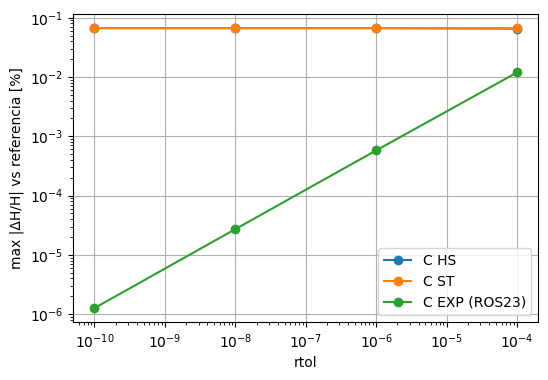

In [10]:
for model in ['HS', 'ST']:
    p = [0.3, 1.0, 70]
    ic = calculate_initial_conditions(p, zi=10, model=model)
    sol = solve_ivp(get_odes, (10, 0), ic, args=(p, model), rtol=1e-8, atol=1e-10, dense_output=True)
    x, y, v, w, r = sol.y
    print(f'{model}: max|w - (1+x+y-v)| = {np.max(np.abs(w - (1 + x + y - v))):.1e}')

fig, ax = plt.subplots(figsize=(6, 4))
rtols = [1e-4, 1e-6, 1e-8, 1e-10]
for model, p in [('HS', [0.3, 1.0, 70]), ('ST', [0.3, 1.0, 70])]:
    ref = H_ER(model, *p, z_grid[::50])
    ax.loglog(rtols, [pct(integrator_c(p, model=model, num_z_points=2000, rtol=rt, atol=rt*1e-2)[1], ref) for rt in rtols], 'o-', label=f'C {model}')
ref = H_EXP_ref([0.3, 1.0, 70], z_grid)
ax.loglog(rtols, [pct(Hubble_c([0.3, 1.0, 70], model='EXP', rtol=rt, atol=rt*1e-2)[1], ref) for rt in rtols], 'o-', label='C EXP (ROS23)')
ax.set_xlabel('rtol'); ax.set_ylabel('max |ΔH/H| vs referencia [%]'); ax.legend(); ax.grid(True)

## 3. $\chi^2$: Python vs C

Con PP+SH0ES + CC + DESI DR2 y parámetros $M=-19.25$, $\Omega_m=0.3$, $H_0=70$.

In [11]:
import chi_square as cs
from data import read_data_pantheon_plus_shoes, read_data_chronometers, read_data_DESI
S = os.path.join(path_git, 'fr_mcmc', 'source')
os.chdir(os.path.join(S, 'Pantheon_plus_shoes'))
ds_PPS = read_data_pantheon_plus_shoes('Pantheon+SH0ES.dat', 'Pantheon+SH0ES_STAT+SYS.cov')
os.chdir(os.path.join(S, 'CC')); ds_CC = read_data_chronometers('chronometers_data.txt')
os.chdir(os.path.join(S, 'DESI')); ds_DESI = read_data_DESI('DESI_DR2_dm_dh.txt', 'DESI_DR2_dv.txt')
kw = dict(dataset_SN_plus_shoes=ds_PPS, dataset_CC=ds_CC, dataset_DESI=ds_DESI)

rows = []
for model, bs in [('LCDM', [None]), ('HS', [0.1, 0.3, 1.0, 2.0]), ('ST', [0.1, 0.3, 1.0, 2.0]), ('EXP', [0.15, 0.3, 1.0, 2.0])]:
    for b in bs:
        th, idx = ([-19.25, 147, 0.3, 70], 4) if model == 'LCDM' else ([-19.25, 147, 0.3, b, 70], 5)
        c = [cs.params_to_chi2(th, None, index=idx, model=model, use_c=u, **kw) for u in (False, True)]
        rows.append(dict(modelo=model, b=b, chi2_py=c[0], chi2_C=c[1], **{'|Δχ²| [%]': 100*abs(c[1]/c[0] - 1), '|Δχ²|': abs(c[1] - c[0])}))
pd.set_option('display.float_format', lambda x: '%.6g' % x)
pd.DataFrame(rows)

,modelo,b,chi2_py,chi2_C,|Δχ²| [%],|Δχ²|
0,LCDM,NaN,2369.56,2369.56,0,0
1,HS,0.1,2562.85,2562.85,7.54952e-13,1.90994e-11
2,HS,0.3,2883.28,2883.28,9.93705e-09,2.86513e-07
3,HS,1,3326.08,3326.08,6.55451e-09,2.18009e-07
4,HS,2,4171.69,4171.69,1.19932e-08,5.00318e-07
5,ST,0.1,2370.45,2370.45,5.32907e-13,1.27329e-11
6,ST,0.3,2375.09,2375.09,8.55915e-10,2.03286e-08
7,ST,1,2096.43,2096.43,2.13796e-10,4.48199e-09
8,ST,2,1852.31,1852.31,6.89448e-12,1.27784e-10
9,EXP,0.15,2369.56,2369.56,2.22045e-14,4.54747e-13


## 4. Resumen

In [12]:
print('max |ΔH/H| Python vs C [%]:')
print(df_H.groupby('modelo')['max|ΔH/H| [%]'].max().to_string())
print()
print('max |ΔH/H| vs formulación independiente (E,R) [%]:')
print(df_ER[['Python vs (E,R) [%]', 'C vs (E,R) [%]']].max().to_string())

max |ΔH/H| Python vs C [%]:
modelo
EXP    2.33008e-06
HS     5.35672e-09
LCDM   4.44089e-14
ST     4.63635e-09

max |ΔH/H| vs formulación independiente (E,R) [%]:
Python vs (E,R) [%]   0.035277
C vs (E,R) [%]        0.035277
